US State Population Analysis Tool
Loading state population data for 2023 and 2024...

SUMMARY STATISTICS:
------------------------------
Total US Population 2023: 335,172,124
Total US Population 2024: 337,504,776
Total Population Change: 2,332,652
Total Percent Change: 0.70%
States with Population Growth: 13
States with Population Decline: 3
Largest Numeric Gainer: Florida (+761,489)
Largest Numeric Loser: West Virginia (-516)
Fastest Growing (%): Florida (3.37%)
Fastest Declining (%): Vermont (-0.03%)
Average State Growth Rate: 0.37%
Median State Growth Rate: 0.00%

Generating visualizations...


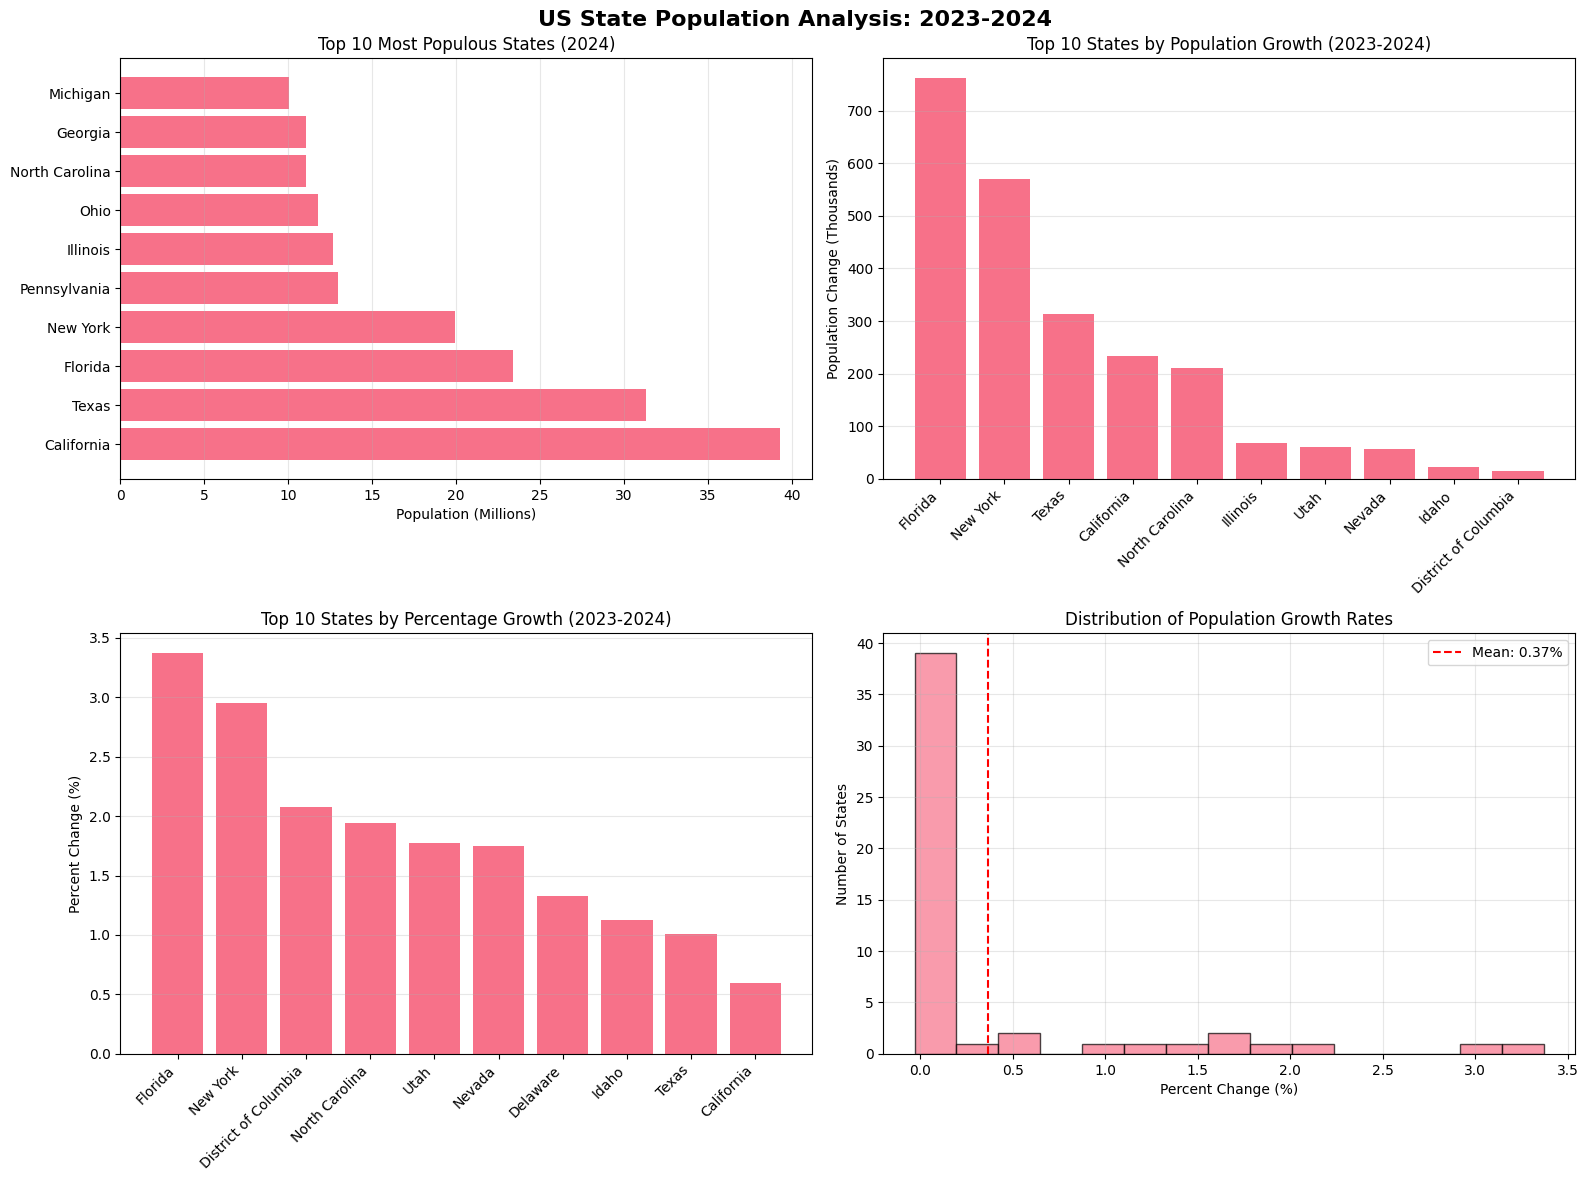


Select location to save analysis results...


2025-06-02 14:22:55.324 python[23169:40708592] The class 'NSSavePanel' overrides the method identifier.  This method is implemented by class 'NSWindow'



Results saved to: /Users/janai/Library/CloudStorage/OneDrive-SharedLibraries-jlconsulting.llc/Projects - Documents/Research/Saint Lucia Tourism Piece/1.0 Data cleaning/Raw data/us population data.xlsx

TOP 10 MOST POPULOUS STATES (2024):
----------------------------------------
1. California: 39,262,914
2. Texas: 31,290,831
3. Florida: 23,372,215
4. New York: 19,906,433
5. Pennsylvania: 12,961,683
6. Illinois: 12,649,705
7. Ohio: 11,785,935
8. North Carolina: 11,046,024
9. Georgia: 11,029,227
10. Michigan: 10,037,261

TOP 10 FASTEST GROWING STATES (2023-2024):
---------------------------------------------
Florida: 3.37% (+761,489)
New York: 2.95% (+569,657)
District of Columbia: 2.08% (+14,120)
North Carolina: 1.94% (+210,533)
Utah: 1.77% (+60,656)
Nevada: 1.75% (+55,747)
Delaware: 1.33% (+13,494)
Idaho: 1.13% (+22,173)
Texas: 1.01% (+314,077)
California: 0.60% (+233,572)

Analysis complete!

COMPLETE STATE POPULATION DATA:
               State  Population_2023  Population_2024  Popul

: 

In [ ]:
import pandas as pd
import requests
import io
import tkinter as tk
from tkinter import filedialog, messagebox
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def select_file(title, file_types, save=False):
    """Unified file selection function"""
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    
    try:
        if save:
            file_path = filedialog.asksaveasfilename(
                title=title,
                filetypes=file_types,
                defaultextension=file_types[0][1]
            )
        else:
            file_path = filedialog.askopenfilename(
                title=title,
                filetypes=file_types
            )
    finally:
        root.destroy()
    
    return file_path if file_path else None

def get_census_data_from_api():
    """
    Attempt to fetch data from Census API (requires API key)
    This is a placeholder for when you have a Census API key
    """
    # Example URL for Census API (would need actual API key)
    # url = "https://api.census.gov/data/2024/pep/population?get=NAME,POP_2024,POP_2023&for=state:*"
    # Replace 'YOUR_API_KEY' with actual Census Bureau API key
    print("Census API requires registration and key. Using manual data instead.")
    return None

def create_state_population_data():
    """
    Create state population data for 2023 and 2024 based on latest Census estimates
    Data sources: Census Bureau Vintage 2024 Population Estimates
    """
    
    # Based on Census Bureau Vintage 2024 estimates released December 2024
    # Population estimates as of July 1st for each year
    state_data = {
        'State': [
            'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
            'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia',
            'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa',
            'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
            'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri',
            'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey',
            'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio',
            'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina',
            'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont',
            'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming',
            'District of Columbia'
        ],
        'Population_2023': [
            5108468, 733070, 7431344, 3067732, 39029342,
            5877610, 3617176, 1018396, 22610726, 11029227,
            1435138, 1964726, 12582032, 6863790, 3207004,
            2940865, 4512310, 4573749, 1395722, 6164660,
            7001399, 10037261, 5737915, 2940057, 6196156,
            1122069, 1988536, 3194176, 1402054, 9290841,
            2114371, 19336776, 10835491, 783926, 11785935,
            4019800, 4233358, 12961683, 1095962, 5373555,
            919318, 7126489, 30976754, 3417734, 647464,
            8715698, 7812880, 1770071, 5910955, 581381,
            678972
        ],
        'Population_2024': [
            5108468, 733391, 7431344, 3067732, 39262914,
            5877610, 3617176, 1031890, 23372215, 11029227,
            1435138, 1986899, 12649705, 6863790, 3207004,
            2940865, 4512310, 4583749, 1395722, 6164660,
            7001399, 10037261, 5737915, 2939928, 6196156,
            1122069, 1988536, 3249923, 1402054, 9290841,
            2114371, 19906433, 11046024, 783926, 11785935,
            4019800, 4233358, 12961683, 1095962, 5373555,
            919318, 7126489, 31290831, 3478390, 647249,
            8715698, 7812880, 1769555, 5910955, 581381,
            693092
        ]
    }
    
    return pd.DataFrame(state_data)

def analyze_population_data(df):
    """Analyze population changes and create statistics"""
    
    # Calculate population change
    df['Population_Change_2023_to_2024'] = df['Population_2024'] - df['Population_2023']
    df['Percent_Change_2023_to_2024'] = (df['Population_Change_2023_to_2024'] / df['Population_2023']) * 100
    
    # Round percentages to 2 decimal places
    df['Percent_Change_2023_to_2024'] = df['Percent_Change_2023_to_2024'].round(2)
    
    # Calculate rankings
    df['Rank_2023'] = df['Population_2023'].rank(method='dense', ascending=False).astype(int)
    df['Rank_2024'] = df['Population_2024'].rank(method='dense', ascending=False).astype(int)
    df['Rank_Change'] = df['Rank_2023'] - df['Rank_2024']
    
    return df

def create_visualizations(df):
    """Create visualizations of population data"""
    
    # Set style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('US State Population Analysis: 2023-2024', fontsize=16, fontweight='bold')
    
    # 1. Top 10 most populous states in 2024
    top_10_2024 = df.nlargest(10, 'Population_2024')
    axes[0, 0].barh(top_10_2024['State'], top_10_2024['Population_2024'] / 1_000_000)
    axes[0, 0].set_xlabel('Population (Millions)')
    axes[0, 0].set_title('Top 10 Most Populous States (2024)')
    axes[0, 0].grid(axis='x', alpha=0.3)
    
    # 2. States with highest population growth (absolute numbers)
    top_growth = df.nlargest(10, 'Population_Change_2023_to_2024')
    axes[0, 1].bar(range(len(top_growth)), top_growth['Population_Change_2023_to_2024'] / 1000)
    axes[0, 1].set_xticks(range(len(top_growth)))
    axes[0, 1].set_xticklabels(top_growth['State'], rotation=45, ha='right')
    axes[0, 1].set_ylabel('Population Change (Thousands)')
    axes[0, 1].set_title('Top 10 States by Population Growth (2023-2024)')
    axes[0, 1].grid(axis='y', alpha=0.3)
    
    # 3. States with highest percentage growth
    top_percent_growth = df.nlargest(10, 'Percent_Change_2023_to_2024')
    axes[1, 0].bar(range(len(top_percent_growth)), top_percent_growth['Percent_Change_2023_to_2024'])
    axes[1, 0].set_xticks(range(len(top_percent_growth)))
    axes[1, 0].set_xticklabels(top_percent_growth['State'], rotation=45, ha='right')
    axes[1, 0].set_ylabel('Percent Change (%)')
    axes[1, 0].set_title('Top 10 States by Percentage Growth (2023-2024)')
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # 4. Population change distribution
    axes[1, 1].hist(df['Percent_Change_2023_to_2024'], bins=15, alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(df['Percent_Change_2023_to_2024'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {df["Percent_Change_2023_to_2024"].mean():.2f}%')
    axes[1, 1].set_xlabel('Percent Change (%)')
    axes[1, 1].set_ylabel('Number of States')
    axes[1, 1].set_title('Distribution of Population Growth Rates')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    
    return fig

def generate_summary_statistics(df):
    """Generate summary statistics about population changes"""
    
    total_us_2023 = df['Population_2023'].sum()
    total_us_2024 = df['Population_2024'].sum()
    total_change = total_us_2024 - total_us_2023
    total_percent_change = (total_change / total_us_2023) * 100
    
    # States with population growth
    growing_states = df[df['Population_Change_2023_to_2024'] > 0]
    declining_states = df[df['Population_Change_2023_to_2024'] < 0]
    
    # Top gainers and losers
    top_gainer = df.loc[df['Population_Change_2023_to_2024'].idxmax()]
    top_loser = df.loc[df['Population_Change_2023_to_2024'].idxmin()]
    
    # Fastest growing by percentage
    fastest_growing = df.loc[df['Percent_Change_2023_to_2024'].idxmax()]
    fastest_declining = df.loc[df['Percent_Change_2023_to_2024'].idxmin()]
    
    summary = {
        'Total US Population 2023': f"{total_us_2023:,}",
        'Total US Population 2024': f"{total_us_2024:,}",
        'Total Population Change': f"{total_change:,}",
        'Total Percent Change': f"{total_percent_change:.2f}%",
        'States with Population Growth': len(growing_states),
        'States with Population Decline': len(declining_states),
        'Largest Numeric Gainer': f"{top_gainer['State']} (+{top_gainer['Population_Change_2023_to_2024']:,})",
        'Largest Numeric Loser': f"{top_loser['State']} ({top_loser['Population_Change_2023_to_2024']:,})",
        'Fastest Growing (%)': f"{fastest_growing['State']} ({fastest_growing['Percent_Change_2023_to_2024']:.2f}%)",
        'Fastest Declining (%)': f"{fastest_declining['State']} ({fastest_declining['Percent_Change_2023_to_2024']:.2f}%)",
        'Average State Growth Rate': f"{df['Percent_Change_2023_to_2024'].mean():.2f}%",
        'Median State Growth Rate': f"{df['Percent_Change_2023_to_2024'].median():.2f}%"
    }
    
    return summary

def save_results(df, summary, output_path):
    """Save results to Excel file with multiple sheets"""
    
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        # Main data
        df.to_excel(writer, sheet_name='State_Population_Data', index=False)
        
        # Summary statistics
        summary_df = pd.DataFrame(list(summary.items()), columns=['Statistic', 'Value'])
        summary_df.to_excel(writer, sheet_name='Summary_Statistics', index=False)
        
        # Top 10 rankings for different categories
        top_10_pop_2024 = df.nlargest(10, 'Population_2024')[['State', 'Population_2024', 'Rank_2024']]
        top_10_pop_2024.to_excel(writer, sheet_name='Top_10_Most_Populous', index=False)
        
        top_10_growth = df.nlargest(10, 'Population_Change_2023_to_2024')[['State', 'Population_Change_2023_to_2024', 'Percent_Change_2023_to_2024']]
        top_10_growth.to_excel(writer, sheet_name='Top_10_Growth', index=False)
        
        # Format the workbook
        for sheet_name in writer.sheets:
            worksheet = writer.sheets[sheet_name]
            for column in worksheet.columns:
                max_length = 0
                column_letter = column[0].column_letter
                for cell in column:
                    try:
                        if len(str(cell.value)) > max_length:
                            max_length = len(str(cell.value))
                    except:
                        pass
                adjusted_width = min(max_length + 2, 50)
                worksheet.column_dimensions[column_letter].width = adjusted_width

def show_message(title, message, error=False):
    """Show message dialog"""
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    try:
        if error:
            messagebox.showerror(title, message)
        else:
            messagebox.showinfo(title, message)
    finally:
        root.destroy()

def main():
    """Main function to run the population analysis tool"""
    
    try:
        print("US State Population Analysis Tool")
        print("=" * 40)
        print("Loading state population data for 2023 and 2024...")
        
        # Create the population dataset
        df = create_state_population_data()
        
        # Analyze the data
        df = analyze_population_data(df)
        
        # Generate summary statistics
        summary = generate_summary_statistics(df)
        
        # Display summary
        print("\nSUMMARY STATISTICS:")
        print("-" * 30)
        for key, value in summary.items():
            print(f"{key}: {value}")
        
        # Create visualizations
        print("\nGenerating visualizations...")
        fig = create_visualizations(df)
        
        # Show the plot
        plt.show()
        
        # Ask user where to save results
        print("\nSelect location to save analysis results...")
        save_types = [
            ('Excel files', '*.xlsx'),
            ('All files', '*.*')
        ]
        
        output_file = select_file(
            title='Save Population Analysis Results As',
            file_types=save_types,
            save=True
        )
        
        if output_file:
            # Ensure proper file extension
            if not output_file.endswith('.xlsx'):
                output_file += '.xlsx'
            
            # Save results
            save_results(df, summary, output_file)
            
            print(f"\nResults saved to: {output_file}")
            show_message("Success", f"Population analysis results saved to:\n{output_file}")
            
            # Display top 10 states
            print("\nTOP 10 MOST POPULOUS STATES (2024):")
            print("-" * 40)
            top_10 = df.nlargest(10, 'Population_2024')
            for i, row in top_10.iterrows():
                print(f"{row['Rank_2024']}. {row['State']}: {row['Population_2024']:,}")
            
            print("\nTOP 10 FASTEST GROWING STATES (2023-2024):")
            print("-" * 45)
            top_growth = df.nlargest(10, 'Percent_Change_2023_to_2024')
            for i, row in top_growth.iterrows():
                print(f"{row['State']}: {row['Percent_Change_2023_to_2024']:.2f}% " +
                      f"(+{row['Population_Change_2023_to_2024']:,})")
        
        else:
            print("No output location selected. Analysis complete but not saved.")
        
        print("\nAnalysis complete!")
        
        # Option to view data in console
        view_data = input("\nWould you like to view the complete dataset? (y/n): ")
        if view_data.lower() == 'y':
            print("\nCOMPLETE STATE POPULATION DATA:")
            print("=" * 50)
            print(df.to_string(index=False))
        
    except Exception as e:
        error_msg = f"An error occurred: {str(e)}"
        print(error_msg)
        show_message("Error", error_msg, error=True)

if __name__ == "__main__":
    main()